<a href="https://colab.research.google.com/github/kashish2610/MLC/blob/main/bpcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print(" Importing libraries...")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("Libraries loaded successfully ")

 Importing libraries...
Libraries loaded successfully 


In [ ]:
print("Defining generator matrix function...")

def generate_G(H):

    M, N = H.shape
    K = N - M

    G = np.zeros((K, N), dtype=int)

    # Identity part
    G[:, :K] = np.eye(K, dtype=int)

    # Random parity part
    G[:, K:] = np.random.randint(0, 2, (K, M))

    return G

print("generate_G ready ")

Defining generator matrix function...
generate_G ready 


In [ ]:
def generate_regular_ldpc(N, K, col_weight=3):
    """
    Generate a regular LDPC parity-check matrix H with:
    - N: code length
    - K: message length
    - col_weight: column weight (number of 1s per column)

    Returns H in sparse (row, col) format.
    """
    M = N - K  # Number of check nodes

    # Initialize empty matrix
    H = np.zeros((M, N), dtype=np.int32)

    # Regular LDPC: each column has col_weight ones
    # Use a structured approach (quasi-cyclic-like)
    rows_per_col = col_weight

    for j in range(N):
        # Place ones at structured positions
        for i in range(rows_per_col):
            row_idx = (j * rows_per_col + i) % M
            H[row_idx, j] = 1

    # Ensure each row has at least one 1
    for i in range(M):
        if np.sum(H[i, :]) == 0:
            H[i, j % N] = 1

    return H


In [ ]:
def H_to_generator_matrix(H):
    """
    Convert parity-check matrix H to generator matrix G.
    G is in systematic form: G = [I_K | P]
    H = [P^T | I_{N-K}] after column permutations

    Returns G in sparse (row, col) format.
    """
    M, N = H.shape
    K = N - M

    # Convert to systematic form using Gaussian elimination
    H_dense = H.copy()

    # Perform Gaussian elimination to get H = [A | I_M]
    pivot_cols = []
    row = 0
    for col in range(N):
        if row >= M:
            break
        # Find pivot
        pivot_row = None
        for r in range(row, M):
            if H_dense[r, col] == 1:
                pivot_row = r
                break

        if pivot_row is not None:
            # Swap rows
            H_dense[[row, pivot_row]] = H_dense[[pivot_row, row]]
            pivot_cols.append(col)

            # Eliminate
            for r in range(M):
                if r != row and H_dense[r, col] == 1:
                    H_dense[r, :] = (H_dense[r, :] + H_dense[row, :]) % 2
            row += 1

    # Information bit positions (non-pivot columns)
    info_cols = [c for c in range(N) if c not in pivot_cols]

    # Build generator matrix G such that H * G^T = 0
    # In systematic form: G = [I_K | P] where P = (H_info)^{-1} * H_parity
    # For simplicity, use the null space approach

    G = np.zeros((K, N), dtype=np.int32)

    # Set systematic part
    for i in range(K):
        G[i, info_cols[i]] = 1

    # Compute parity part: for each info bit, find corresponding parity bits
    # H_par @ x_par = H_info @ x_info (mod 2)
    H_info = H_dense[:, info_cols]
    H_parity = H_dense[:, pivot_cols]

    # Solve for each row of G
    num_pivots = len(pivot_cols)
    for i in range(K):
        # Target: H_parity @ p = H_info @ e_i (where e_i is unit vector)
        target = H_info[:, i].copy()

        # Solve H_parity @ p = target using Gaussian elimination
        # Use only the pivot columns/rows that exist
        aug = np.hstack([H_parity[:, :num_pivots].copy(), target.reshape(-1, 1)])

        # Forward elimination
        for col in range(num_pivots):
            pivot = None
            for r in range(col, num_pivots):
                if aug[r, col] == 1:
                    pivot = r
                    break
            if pivot is not None:
                aug[[col, pivot]] = aug[[pivot, col]]
                for r in range(num_pivots):
                    if r != col and aug[r, col] == 1:
                        aug[r, :] = (aug[r, :] + aug[col, :]) % 2

        # Extract solution
        for j, pc in enumerate(pivot_cols):
            if j < num_pivots:
                G[i, pc] = aug[j, num_pivots]

    return G


In [ ]:
print("\nGenerating LDPC matrices...")

N = 576
K = 432

H = generate_regular_ldpc(N, K)
G = H_to_generator_matrix(H)

print("H shape:", H.shape)
print("G shape:", G.shape)

# verification
print("Check H·G^T = 0:",
      np.sum(np.mod(G @ H.T, 2)) == 0)


Generating LDPC matrices...
H shape: (144, 576)
G shape: (432, 576)
Check H·G^T = 0: True


In [ ]:
print("Defining LDPC encoder...")
def ldpc_encode(msg, G):
    return np.mod(msg @ G, 2)

print("Encoder ready ")

Defining LDPC encoder...
Encoder ready 


In [ ]:
print(" Defining channel model")

def bpsk_mod(bits):
    return 2*bits - 1

def correlated_noise(x, snr_db, rho=0.9):   #  change 0.7 → 0.9
    snr = 10**(snr_db/10)
    sigma = np.sqrt(1/(2*snr))

    w = sigma*np.random.randn(len(x))
    noise = np.zeros(len(x))

    for i in range(1,len(x)):
        noise[i] = rho*noise[i-1] + w[i]

    y = x + noise

    return y, noise

print("Channel model ready ")

 Defining channel model
Channel model ready 


In [ ]:
class BP_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(1, 64, 5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 64, 5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 64, 5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 64, 5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 64, 5, padding=2),
            nn.ReLU(),

            nn.Conv1d(64, 1, 5, padding=2)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
print(" Generating CORRECT training data (residual)")

def generate_training_data(samples, H, bp_decoder):

    n = H.shape[1]

    X = []
    Y = []

    for _ in range(samples):

        msg = np.random.randint(0,2,K)
        codeword = ldpc_encode(msg, G)
        x = 2*codeword - 1
        y, noise = correlated_noise(x, np.random.choice([-2,0,2,4]))

        # ---- FIRST BP ----
        llr = 2*y
        llr = llr.reshape(1,-1)

        decoded = bp_decoder.decode(llr, 25)[0]

        # ---- RESIDUAL NOISE (IMPORTANT) ----
        noise_input = y - (decoded * (-2) + 1)

        X.append(noise_input)
        Y.append(noise)

    X = torch.tensor(X).float().unsqueeze(1)
    Y = torch.tensor(Y).float().unsqueeze(1)

    print("Training data shape:", X.shape)

    return X, Y

 Generating CORRECT training data (residual)


In [ ]:
print("Initializing BP decoder")

import torch
import numpy as np


class GetMatrixForBPNet:
    """Calculates the matrices used to perform BP process with matrix operations."""

    def __init__(self, test_H, loc_nzero_row):
        print("Construct the Matrices H class!\n")
        self.H = test_H
        self.m, self.n = np.shape(test_H)
        self.H_sum_line = np.sum(self.H, axis=0)   # degree of each variable node
        self.H_sum_row = np.sum(self.H, axis=1)    # degree of each check node
        self.loc_nzero_row = loc_nzero_row
        self.num_all_edges = np.size(self.loc_nzero_row[1, :])

        # Build sorted edge index arrays (row-major and column-major orderings)
        self.loc_nzero1 = self.loc_nzero_row[1, :] * self.n + self.loc_nzero_row[0, :]
        self.loc_nzero2 = np.sort(self.loc_nzero1)
        self.loc_nzero_line = np.append(
            [np.mod(self.loc_nzero2, self.n)],
            [self.loc_nzero2 // self.n],
            axis=0
        )
        self.loc_nzero4 = self.loc_nzero_line[0, :] * self.n + self.loc_nzero_line[1, :]
        self.loc_nzero5 = np.sort(self.loc_nzero4)

    def get_Matrix_VC(self):
        """Returns matrices needed for the Variable-to-Check message pass."""
        H_x_to_xe0 = np.zeros([self.num_all_edges, self.n], np.float32)
        H_sum_by_V_to_C = np.zeros([self.num_all_edges, self.num_all_edges], dtype=np.float32)
        H_xe_last_to_y = np.zeros([self.n, self.num_all_edges], dtype=np.float32)
        Map_row_to_line = np.zeros([self.num_all_edges], dtype=np.int32)

        for i in range(self.num_all_edges):
            Map_row_to_line[i] = int(np.where(self.loc_nzero1 == self.loc_nzero2[i])[0][0])

        map_H_row_to_line = np.zeros([self.num_all_edges, self.num_all_edges], dtype=np.float32)
        for i in range(self.num_all_edges):
            map_H_row_to_line[i, Map_row_to_line[i]] = 1

        count = 0
        for i in range(self.n):
            temp = count + self.H_sum_line[i]
            H_sum_by_V_to_C[count:temp, count:temp] = 1
            H_xe_last_to_y[i, count:temp] = 1
            H_x_to_xe0[count:temp, i] = 1
            for j in range(self.H_sum_line[i]):
                H_sum_by_V_to_C[count + j, count + j] = 0
            count = count + self.H_sum_line[i]

        print("Return Matrices V-C successfully!\n")
        # Use float64 for matrix multiplication to prevent overflow, then convert back
        H_sumV_to_C = np.matmul(H_sum_by_V_to_C.astype(np.float64), map_H_row_to_line.astype(np.float64)).astype(np.float32)
        H_xe_to_y = np.matmul(H_xe_last_to_y.astype(np.float64), map_H_row_to_line.astype(np.float64)).astype(np.float32)
        return H_x_to_xe0, H_sumV_to_C, H_xe_to_y

    def get_Matrix_CV(self):
        """Returns the matrix needed for the Check-to-Variable message pass."""
        H_sum_by_C_to_V = np.zeros([self.num_all_edges, self.num_all_edges], dtype=np.float32)
        Map_line_to_row = np.zeros([self.num_all_edges], dtype=np.int32)

        for i in range(self.num_all_edges):
            Map_line_to_row[i] = int(np.where(self.loc_nzero4 == self.loc_nzero5[i])[0][0])

        map_H_line_to_row = np.zeros([self.num_all_edges, self.num_all_edges], dtype=np.float32)
        for i in range(np.size(self.loc_nzero1)):
            map_H_line_to_row[i, Map_line_to_row[i]] = 1

        count = 0
        for i in range(self.m):
            temp = count + self.H_sum_row[i]
            H_sum_by_C_to_V[count:temp, count:temp] = 1
            for j in range(self.H_sum_row[i]):
                H_sum_by_C_to_V[count + j, count + j] = 0
            count = count + self.H_sum_row[i]

        print("Return Matrices C-V successfully!\n")
        # Use float64 for matrix multiplication to prevent overflow, then convert back
        return np.matmul(H_sum_by_C_to_V.astype(np.float64), map_H_line_to_row.astype(np.float64)).astype(np.float32)


class BP_NetDecoder:
    """Belief Propagation decoder implemented in PyTorch."""

    def __init__(self, H, batch_size):
        _, self.v_node_num = np.shape(H)
        ii, jj = np.nonzero(H)
        loc_nzero_row = np.array([ii, jj])
        self.num_all_edges = np.size(loc_nzero_row[1, :])

        gm1 = GetMatrixForBPNet(H[:, :], loc_nzero_row)
        H_sumC_to_V = gm1.get_Matrix_CV()
        H_x_to_xe0, H_sumV_to_C, H_xe_v_sumc_to_y = gm1.get_Matrix_VC()

        self.batch_size = batch_size
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Register constant matrices as buffers (not trained)
        self.H_sumC_to_V = torch.tensor(H_sumC_to_V, dtype=torch.float32, device=self.device)
        self.H_sumV_to_C = torch.tensor(H_sumV_to_C, dtype=torch.float32, device=self.device)
        self.H_x_to_xe0 = torch.tensor(H_x_to_xe0, dtype=torch.float32, device=self.device)
        self.H_xe_v_sumc_to_y = torch.tensor(H_xe_v_sumc_to_y, dtype=torch.float32, device=self.device)

        print(f"BP_NetDecoder initialised on device: {self.device}")

    @staticmethod
    def _atanh(x: torch.Tensor) -> torch.Tensor:
        """Numerically stable atanh."""
        return torch.atanh(x.clamp(-1 + 1e-7, 1 - 1e-7))

    def _one_bp_iteration(
        self,
        xe_v2c: torch.Tensor,
        xe_0: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """One full BP iteration: V->C then C->V."""
        # C-to-V update (check node processing)

        xe_v2c = torch.clamp(xe_v2c, -10.0, 10.0)

        xe_tanh = torch.tanh(xe_v2c / 2.0)
        xe_tanh_sign = torch.sign(xe_tanh)

        # Compute product of tanh values in log domain for numerical stability
        xe_sum_log_img = self.H_sumC_to_V @ (((1 - xe_tanh_sign) / 2.0) * torch.pi)
        xe_sum_log_real = self.H_sumC_to_V @ torch.log(torch.clamp(torch.abs(xe_tanh), min=1e-6))

        # Reconstruct the product using complex exponential trick
        xe_product = torch.exp(xe_sum_log_real) * torch.cos(xe_sum_log_img)
        # cid atanh overflow
        xe_product = torch.clamp(xe_product, -0.999999, 0.999999)



        xe_v_sumc = self._atanh(xe_product) * 2.0   # C->V messages

        # V-to-C update (variable node processing)
        xe_c_sumv = xe_0 + self.H_sumV_to_C @ xe_v_sumc  # V->C messages

        return xe_v_sumc, xe_c_sumv

    def decode(self, llr_in: np.ndarray, bp_iter_num: int) -> np.ndarray:
        """
        Run BP decoding.

        Args:
            llr_in:      Input LLR array of shape (real_batch_size, n).
            bp_iter_num: Number of BP iterations.

        Returns:
            Hard-decision output array of shape (real_batch_size, n).
        """
        real_batch_size, num_v_node = llr_in.shape

        # Zero-pad to self.batch_size if necessary
        if real_batch_size != self.batch_size:
            pad = np.zeros(
                [self.batch_size - real_batch_size, num_v_node], dtype=np.float32
            )
            llr_in = np.concatenate([llr_in, pad], axis=0)

        # shape: (v_node_num, batch_size)  – column-oriented to match original
        llr_t = torch.tensor(llr_in, dtype=torch.float32, device=self.device).T

        # Initialisation: spread channel LLRs to all edges
        xe_0 = self.H_x_to_xe0 @ llr_t          # (num_edges, batch_size)
        xe_v2c = xe_0.clone()                     # initial V->C messages

        # Iterative decoding
        for _ in range(bp_iter_num - 1):
            _, xe_v2c = self._one_bp_iteration(xe_v2c, xe_0)

        xe_v_sumc, _ = self._one_bp_iteration(xe_v2c, xe_0)

        # Marginal LLR and hard decision
        bp_out_llr = llr_t + self.H_xe_v_sumc_to_y @ xe_v_sumc  # (n, batch_size)
        dec_out = ((1 - torch.sign(bp_out_llr).int()) // 2).T    # (batch_size, n)

        y_dec = dec_out.cpu().numpy()
        if real_batch_size != self.batch_size:
            y_dec = y_dec[:real_batch_size, :]

        return y_dec


bp_decoder = BP_NetDecoder(H, batch_size=1)

print("BP decoder ready ")

Initializing BP decoder
Construct the Matrices H class!

Return Matrices C-V successfully!

Return Matrices V-C successfully!

BP_NetDecoder initialised on device: cuda
BP decoder ready 


In [ ]:
print(" Initializing BP Decoder")

# define code length
n = H.shape[1]

# create BP decoder
bp_decoder = BP_NetDecoder(H, batch_size=1)

print("BP Decoder initialized ")
print("Code length n =", n)

 Initializing BP Decoder
Construct the Matrices H class!

Return Matrices C-V successfully!

Return Matrices V-C successfully!

BP_NetDecoder initialised on device: cuda
BP Decoder initialized 
Code length n = 576


In [ ]:
print("Generate data")
X_train, Y_train = generate_training_data(8000, H, bp_decoder)

Generate data


/tmp/ipykernel_6830/1537894473.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(X).float().unsqueeze(1)


Training data shape: torch.Size([8000, 1, 576])


In [ ]:
X2, Y2 = generate_training_data(8000, H, bp_decoder)

Training data shape: torch.Size([8000, 1, 576])


In [ ]:
"""device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
X_train = X_train.to(device)
Y_train = Y_train.to(device)

print("Using device:", device)"""

Using device: cuda


In [ ]:
def train_model(model, X_train, Y_train, epochs=50):

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    batch_size = 128

    for epoch in range(epochs):

        perm = torch.randperm(X_train.size(0))

        for i in range(0, X_train.size(0), batch_size):

            idx = perm[i:i+batch_size]

            x_batch = X_train[idx].to(device)
            y_batch = Y_train[idx].to(device)

            optimizer.zero_grad()

            pred = model(x_batch)
            loss = criterion(pred, y_batch)

            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

    return model

In [ ]:

print("Initializing multi-stage CNN models...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model1 = BP_CNN().to(device)
model2 = BP_CNN().to(device)
model3 = BP_CNN().to(device)

print("Models ready ")

Initializing multi-stage CNN models...
Models ready 


In [ ]:
model1 = train_model(model1, X_train, Y_train)


model2 = train_model(model2, X2, Y2)

model3 = train_model(model3, X2, Y2)

Epoch 0: Loss = 0.3819
Epoch 1: Loss = 0.3317
Epoch 2: Loss = 0.3289
Epoch 3: Loss = 0.2852
Epoch 4: Loss = 0.2975
Epoch 5: Loss = 0.3295
Epoch 6: Loss = 0.3280
Epoch 7: Loss = 0.3109
Epoch 8: Loss = 0.2935
Epoch 9: Loss = 0.3124
Epoch 10: Loss = 0.2501
Epoch 11: Loss = 0.2459
Epoch 12: Loss = 0.3129
Epoch 13: Loss = 0.2990
Epoch 14: Loss = 0.2957
Epoch 15: Loss = 0.2706
Epoch 16: Loss = 0.2960
Epoch 17: Loss = 0.3030
Epoch 18: Loss = 0.3025
Epoch 19: Loss = 0.2407
Epoch 20: Loss = 0.2853
Epoch 21: Loss = 0.2488
Epoch 22: Loss = 0.3126
Epoch 23: Loss = 0.3161
Epoch 24: Loss = 0.3028
Epoch 25: Loss = 0.2983
Epoch 26: Loss = 0.2805
Epoch 27: Loss = 0.2403
Epoch 28: Loss = 0.2498
Epoch 29: Loss = 0.2835
Epoch 30: Loss = 0.2971
Epoch 31: Loss = 0.2656
Epoch 32: Loss = 0.2962
Epoch 33: Loss = 0.2980
Epoch 34: Loss = 0.2597
Epoch 35: Loss = 0.2379
Epoch 36: Loss = 0.2674
Epoch 37: Loss = 0.3115
Epoch 38: Loss = 0.2656
Epoch 39: Loss = 0.3076
Epoch 40: Loss = 0.2859
Epoch 41: Loss = 0.2720
Ep

In [ ]:
def correlated_noise(x, snr_db, rho=0.95):

    snr = 10**(snr_db/10)
    sigma = np.sqrt(1/(2*snr))

    w = sigma*np.random.randn(len(x))
    noise = np.zeros(len(x))

    for i in range(1,len(x)):
        noise[i] = rho*noise[i-1] + w[i]

    return x + noise, noise

In [ ]:
print("\nRunning CORRECT Iterative BP-CNN...")

import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# move model to GPU
model1 = model1.to(device)

snr_range = np.arange(-2, 7)

ber_bp = []
ber_cnn = []

K = G.shape[0]
N = G.shape[1]

for snr in snr_range:

    print(f"\nSNR = {snr}")

    errors_bp = 0
    errors_cnn = 0
    total_bits = 0

    for _ in range(100):

        # =========================
        # DATA
        # =========================
        msg = np.random.randint(0, 2, K)
        codeword = ldpc_encode(msg, G)

        # BPSK
        x = 1 - 2 * codeword

        # Channel
        y, noise = correlated_noise(x, snr)

        y = y.flatten()
        noise = noise.flatten()

        # =========================
        # BP BASELINE
        # =========================
        llr_bp = 2 * y
        decoded_bp = bp_decoder.decode(llr_bp.reshape(1, -1), 50)[0]

        errors_bp += np.sum(codeword != decoded_bp)

        # =========================
        # BP → CNN → BP
        # =========================

        # ---- First BP ----
        llr = 2 * y
        decoded = bp_decoder.decode(llr.reshape(1, -1), 25)[0]

        # ---- Residual ----
        x_est = 1 - 2 * decoded
        noise_input = y - x_est

        # ---- Normalize ----
        std = np.std(noise_input) + 1e-8
        noise_input = noise_input / std

        # ---- CNN ----
        noise_tensor = torch.tensor(noise_input, dtype=torch.float32)\
                            .unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            noise_hat = model1(noise_tensor).cpu().numpy().flatten()

        # ---- Scale control (IMPORTANT) ----
        noise_hat = 0.7 * noise_hat

        # ---- Clean ----
        y_clean = y - noise_hat




        # ---- Second BP ----
        llr = 2 * y_clean
        decoded_cnn = bp_decoder.decode(llr.reshape(1, -1), 25)[0]

        errors_cnn += np.sum(codeword != decoded_cnn)

        # correct bit count
        total_bits += N

    # =========================
    # BER
    # =========================
    ber_bp.append(errors_bp / total_bits)
    ber_cnn.append(errors_cnn / total_bits)

    print(f"BER BP: {ber_bp[-1]:.6f}")
    print(f"BER BP-CNN: {ber_cnn[-1]:.6f}")


Running CORRECT Iterative BP-CNN...
Using device: cuda

SNR = -2
BER BP: 0.479838
BER BP-CNN: 0.467199

SNR = -1
BER BP: 0.454699
BER BP-CNN: 0.432454

SNR = 0
BER BP: 0.438171
BER BP-CNN: 0.400000

SNR = 1
BER BP: 0.415833
BER BP-CNN: 0.355394

SNR = 2
BER BP: 0.389491
BER BP-CNN: 0.285579

SNR = 3
BER BP: 0.350949
BER BP-CNN: 0.220023

SNR = 4
BER BP: 0.325833
BER BP-CNN: 0.166227

SNR = 5
BER BP: 0.285208
BER BP-CNN: 0.117616

SNR = 6
BER BP: 0.253264
BER BP-CNN: 0.091481


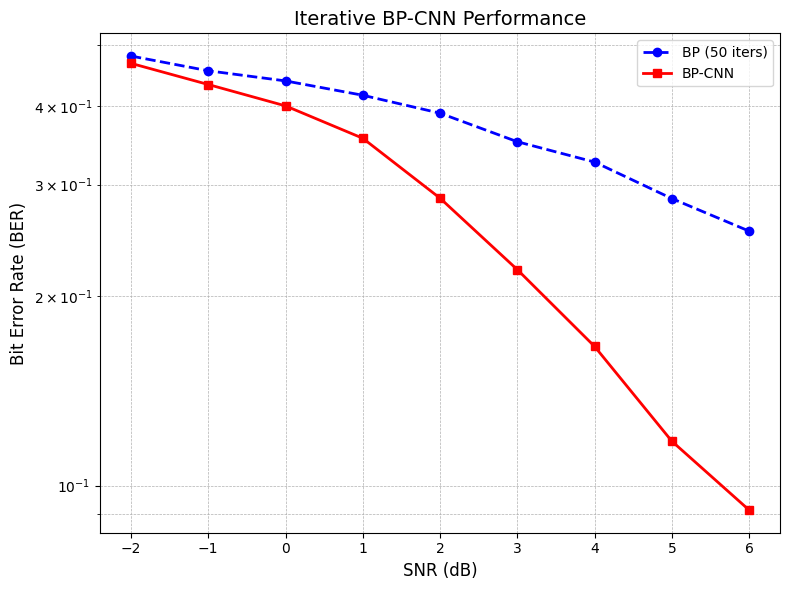

In [ ]:
plt.figure(figsize=(8,6))

# Plot curves
plt.semilogy(snr_range, ber_bp, 'bo--', linewidth=2, markersize=6, label="BP (50 iters)")
plt.semilogy(snr_range, ber_cnn, 'rs-', linewidth=2, markersize=6, label="BP-CNN")

# Labels
plt.xlabel("SNR (dB)", fontsize=12)
plt.ylabel("Bit Error Rate (BER)", fontsize=12)

# Title
plt.title("Iterative BP-CNN Performance", fontsize=14)

# Grid (important for log plots)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Legend
plt.legend()

plt.tight_layout()
plt.show()